In [6]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [93]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import seaborn as sns

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from metric import calculate_discriminative_tv_qda
import json

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Setting parameters


In [114]:
from data_generator import generate_data
from RFsampler_modules import geom_timegrid_generator, lin_timegrid_generator, MytrueEulerSampler, MynewSDE_timegrid_generator, Mynew_trueSDESampler
from RFmodules import VelocityNet
from tqdm import tqdm

DIMENSIONS = [int(i) for i in np.linspace(100, 300, num = 10)]   #[int(i) for i in np.logspace(2, 3, num = 4)]
RANKS = [int(i) for i in np.linspace(3, 40, num = 5)]
N_STEPS = [int(i) for i in np.linspace(10, 200, num = 5)]
TV_tol = 0.1
ROUNDS = 3
#####################################
n_samples = 2000
INPUT_DIM = 800
RANK = 8
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'low_rank_Gaussian'  # 'low_rank_Gaussian' or 'two_moons'

NUM_STEPS = 100 # Number of time steps for sampling
NUM_SAMPLES = 2000 # Number of samples to Generate
####################################

In [116]:
TV_geom_list = []
TV_lin_list = []
TV_sde_list = []
dimensions_list = []

N_ode_geom = np.inf
N_ode_lin = np.inf
N_sde = np.inf

N_ode_geom_matrix = np.zeros((len(DIMENSIONS), len(RANKS)))
N_ode_lin_matrix = np.zeros((len(DIMENSIONS), len(RANKS)))
N_sde_matrix = np.zeros((len(DIMENSIONS), len(RANKS)))

for INPUT_DIM in DIMENSIONS:
    # generate data
    
    CENTER = torch.ones(INPUT_DIM) * 8.0  
    
    for RANK in RANKS:
       
        # Original target distribution
        D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)

        for NUM_STEPS in N_STEPS:
            
            for rounds in tqdm(range(ROUNDS), desc=f"DIM {INPUT_DIM}, RANK {RANK}, STEPS {NUM_STEPS}"):
                pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
                D0 = pi_0.sample([n_samples])
                # instead generate univariate D_0 nxd times and cast it torch tensor
                #D0 = torch.randn(n_samples, INPUT_DIM, device=device)
               
                TV_geom = 0
                TV_lin = 0
                TV_sde = 0
                # print(f"Dimension: {INPUT_DIM}, Round: {rounds+1}")

                

                
                
                # Fluff RF model
                straight_rf = RectifiedFlow(
                    data_shape=(INPUT_DIM,),
                    velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
                    interp="straight",
                    source_distribution=pi_0,
                    device=device,
                )

                
                # generate trajectories using true velocity field
                
                
                true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
                    time_grid = lin_timegrid_generator(NUM_STEPS),
                    rectified_flow = straight_rf,
                    num_samples= NUM_SAMPLES,
                )

                true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
                    time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
                    rectified_flow = straight_rf,
                    num_samples= NUM_SAMPLES,
                )

                true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
                true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)

                true_sde_sampler = Mynew_trueSDESampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
                    rectified_flow=straight_rf,
                    time_grid = MynewSDE_timegrid_generator(NUM_STEPS , c0 = 2, c1 = 5), # 900, c0 = 5, c1 = 10.5
                    num_samples= NUM_SAMPLES,
                )
                true_traj_sde = true_sde_sampler.sample_loop(seed=100)

                # Caluclate TV-QDA between generated samples and real data samples at a certain time step
                geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
                lin_time_grid = lin_timegrid_generator(NUM_STEPS)
                sde_time_grid = MynewSDE_timegrid_generator(NUM_STEPS, c0 = 2, c1 = 5)
                pos  = 2  # Position in the time grid to evaluate
                blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
                blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
                blurred_Real_Data_sde = D1[:NUM_SAMPLES] * sde_time_grid[-1] + D0[:NUM_SAMPLES] * (1 - sde_time_grid[-1])

                blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
                blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
                blurred_Real_Data_sde = blurred_Real_Data_sde.cpu().numpy()  # Real data samples from distribution p_1

                Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
                Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid
                Gen_Data_sde = true_traj_sde.trajectories[-1].cpu().numpy()  # Generated data samples from SDE sampler
                
                tv_qda_geom = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_geom)
                tv_qda_lin = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_lin)
                tv_qda_sde = calculate_discriminative_tv_qda(blurred_Real_Data_sde, Gen_Data_sde)

                TV_geom += tv_qda_geom
                TV_lin += tv_qda_lin
                TV_sde += tv_qda_sde

            

            mean_TV_geom = np.mean(TV_geom)
            mean_TV_lin = np.mean(TV_lin)
            mean_TV_sde = np.mean(TV_sde)


            if mean_TV_geom < TV_tol:
                N_ode_geom = min(NUM_STEPS, N_ode_geom)
            if mean_TV_lin < TV_tol:
                N_ode_lin = min(NUM_STEPS, N_ode_lin)
            if mean_TV_sde < TV_tol:
                N_sde = min(NUM_STEPS, N_sde)
                

            # store the Ns in the matrices
            N_ode_geom_matrix[DIMENSIONS.index(INPUT_DIM), RANKS.index(RANK)] = N_ode_geom
            N_ode_lin_matrix[DIMENSIONS.index(INPUT_DIM), RANKS.index(RANK)] = N_ode_lin
            N_sde_matrix[DIMENSIONS.index(INPUT_DIM), RANKS.index(RANK)] = N_sde
            # TV_lin_list.append(np.mean(TV_lin))
            # TV_sde_list.append(np.mean(TV_sde))
            # dimensions_list.append(INPUT_DIM)
            
            # save intermediate results as json
            
            results = {
                "N_ode_geom_matrix": N_ode_geom_matrix.tolist(),
                "N_ode_lin_matrix": N_ode_lin_matrix.tolist(),
                "N_sde_matrix": N_sde_matrix.tolist()
            }
            #print(results)
            # create json file of specific name
            name = f"assets/N_matrix_TVtol_{TV_tol}_low_rank_Gaussian_TV_results.json"
            with open(name, "w") as f:
                json.dump(results, f)   

DIM 233, RANK 12, STEPS 200:  33%|███▎      | 1/3 [00:46<01:32, 46.48s/it]


KeyboardInterrupt: 

In [56]:
mean_TV_geom, mean_TV_lin, mean_TV_sde  

(0.014399999999999946, 1.0, 0.01649999999999996)

In [ ]:
N1 = json.load(open(f"assets/N_matrix_TVtol_{0.01}_low_rank_Gaussian_TV_results.json", "r"))
N2 = json.load(open(f"assets/N_matrix_TVtol_{0.03}_low_rank_Gaussian_TV_results.json", "r"))
N3 = json.load(open(f"assets/N_matrix_TVtol_{0.05}_low_rank_Gaussian_TV_results.json", "r"))
N4 = json.load(open(f"assets/N_matrix_TVtol_{0.07}_low_rank_Gaussian_TV_results.json", "r"))
N5 = json.load(open(f"assets/N_matrix_TVtol_{0.1}_low_rank_Gaussian_TV_results.json", "r"))


DIMENSIONS = [int(i) for i in np.linspace(100, 300, num = 10)]
RANKS = [int(i) for i in np.linspace(50, 80, num = 4)]

# Plotting k/N for varying k with fixed dimension


In [78]:
N4

{'N_ode_geom_matrix': [[50.0, 50.0, 50.0, 50.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [30.0, 30.0, 30.0, 30.0],
  [30.0, 30.0, 30.0, 30.0],
  [30.0, 30.0, 30.0, 30.0]],
 'N_ode_lin_matrix': [[100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0],
  [100.0, 100.0, 100.0, 100.0]],
 'N_sde_matrix': [[80.0, 80.0, 80.0, 80.0],
  [70.0, 70.0, 70.0, 70.0],
  [50.0, 50.0, 50.0, 50.0],
  [50.0, 50.0, 50.0, 50.0],
  [50.0, 50.0, 50.0, 50.0],
  [50.0, 50.0, 50.0, 50.0],
  [40.0, 40.0, 40.0, 40.0],
  [40.0, 40.0, 40.0, 40.0],
  [30.0, 30.0, 30.0, 30.0],
  [30.0, 30.0, 30.0, 30.0]]}

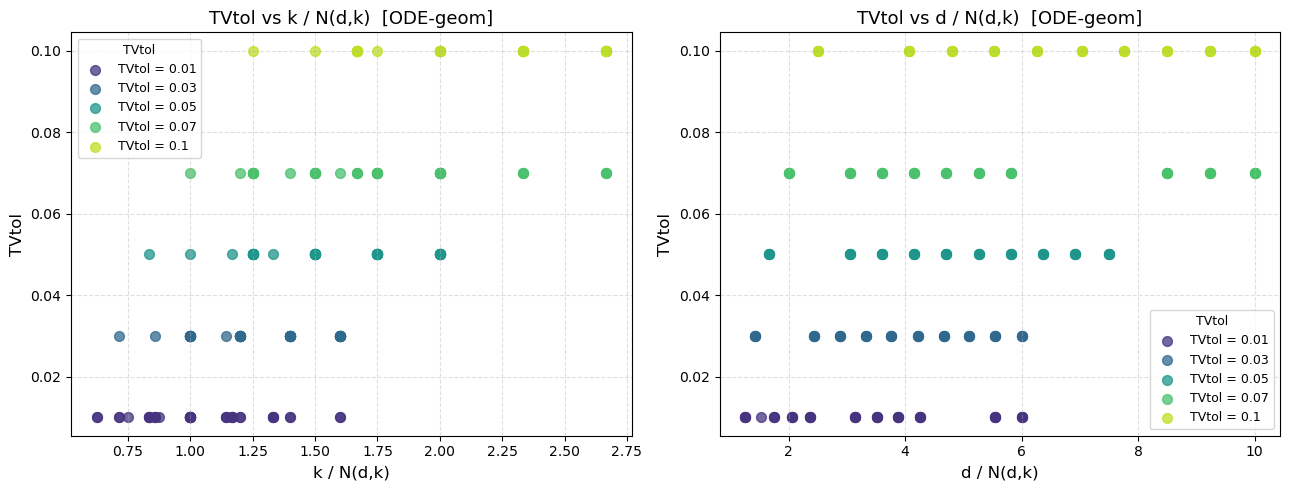

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── data ──────────────────────────────────────────────────────────────────────
datasets = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]

method_key = "N_ode_geom_matrix"

# ── helper to extract (ratio, TVtol) pairs ────────────────────────────────────
def collect_points(numerator="k"):
    """
    numerator = 'k'  → ratio = k / N(d,k)
    numerator = 'd'  → ratio = d / N(d,k)
    Returns list of (tvtol, ratio) tuples; inf N are skipped.
    """
    points = []
    for tol, data in datasets.items():
        matrix = data[method_key]           # shape: (len(DIMS), len(RANKS))
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    points.append((tol, num / N))
    return points

# ── plot factory ──────────────────────────────────────────────────────────────
def make_plot(numerator, ax, title, xlabel):
    points  = collect_points(numerator)
    tols    = np.array([p[0] for p in points])
    ratios  = np.array([p[1] for p in points])

    # colour by TVtol level
    tol_levels = sorted(datasets.keys())
    colors     = cm.viridis(np.linspace(0.15, 0.9, len(tol_levels)))
    cmap       = {t: c for t, c in zip(tol_levels, colors)}

    for tol in tol_levels:
        mask = tols == tol
        ax.scatter(ratios[mask], tols[mask],
                   color=cmap[tol], alpha=0.75, s=50,
                   label=f"TVtol = {tol}")

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("TVtol", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(title="TVtol", fontsize=9, title_fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

# ── two-panel figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

make_plot("k", axes[0],
          title  = "TVtol vs k / N(d,k)  [ODE-geom]",
          xlabel = "k / N(d,k)")

make_plot("d", axes[1],
          title  = "TVtol vs d / N(d,k)  [ODE-geom]",
          xlabel = "d / N(d,k)")

plt.tight_layout()
#plt.savefig("TVtol_vs_ratios_ode_geom.pdf", bbox_inches="tight")
plt.show()

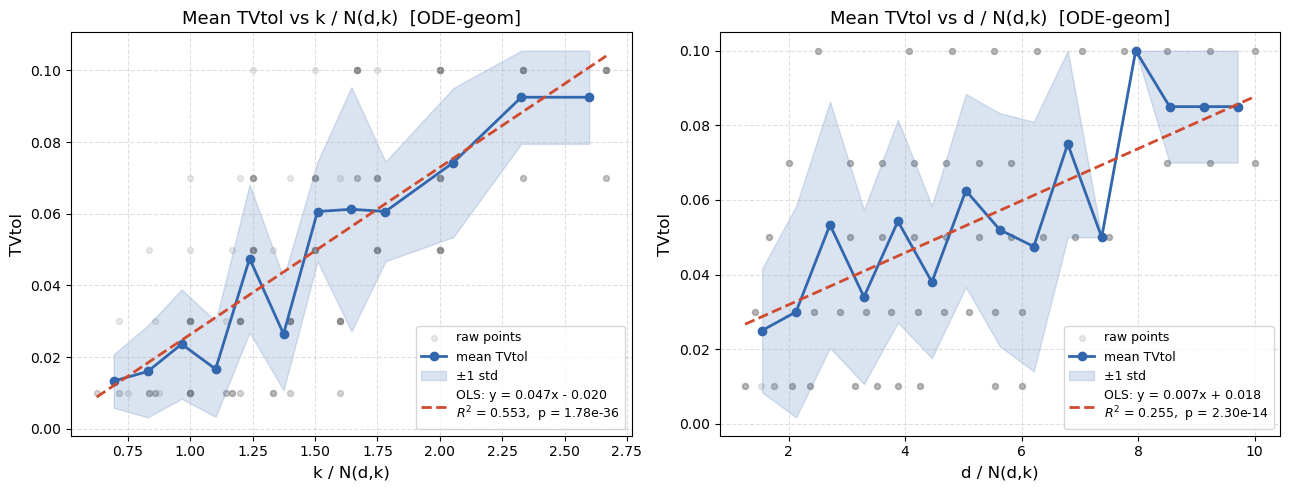

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, linregress

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

def collect_points(numerator="k"):
    points = []
    for tol, data in datasets.items():
        matrix = data[method_key]
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    points.append((tol, num / N))
    return points

def plot_mean_tvtol(numerator, ax, title, xlabel, n_bins=15):
    points = collect_points(numerator)
    tols   = np.array([p[0] for p in points])
    ratios = np.array([p[1] for p in points])

    # ── binned mean ───────────────────────────────────────────────────────────
    means, bin_edges, _ = binned_statistic(ratios, tols, statistic="mean", bins=n_bins)
    stds,  _,         _ = binned_statistic(ratios, tols, statistic="std",  bins=n_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    valid = ~np.isnan(means)
    xc, ym, ys = bin_centers[valid], means[valid], stds[valid]

    ax.scatter(ratios, tols, color="gray", alpha=0.18, s=18, zorder=0, label="raw points")
    ax.plot(xc, ym, marker="o", linewidth=2, markersize=6, color="#3266ad", label="mean TVtol")
    ax.fill_between(xc, ym - ys, ym + ys, alpha=0.18, color="#3266ad", label="±1 std")

    # ── OLS on raw points ─────────────────────────────────────────────────────
    slope, intercept, r, p, se = linregress(ratios, tols)
    x_line = np.linspace(ratios.min(), ratios.max(), 200)
    y_line = slope * x_line + intercept

    sign   = "+" if intercept >= 0 else "-"
    label  = (f"OLS: y = {slope:.3f}x {sign} {abs(intercept):.3f}\n"
              f"$R^2$ = {r**2:.3f},  p = {p:.2e}")
    ax.plot(x_line, y_line, color="#d04a2f", linewidth=2,
            linestyle="--", zorder=4, label=label)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("TVtol", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_mean_tvtol("k", axes[0],
                title  = "Mean TVtol vs k / N(d,k)  [ODE-geom]",
                xlabel = "k / N(d,k)")

plot_mean_tvtol("d", axes[1],
                title  = "Mean TVtol vs d / N(d,k)  [ODE-geom]",
                xlabel = "d / N(d,k)")

plt.tight_layout()
plt.show()

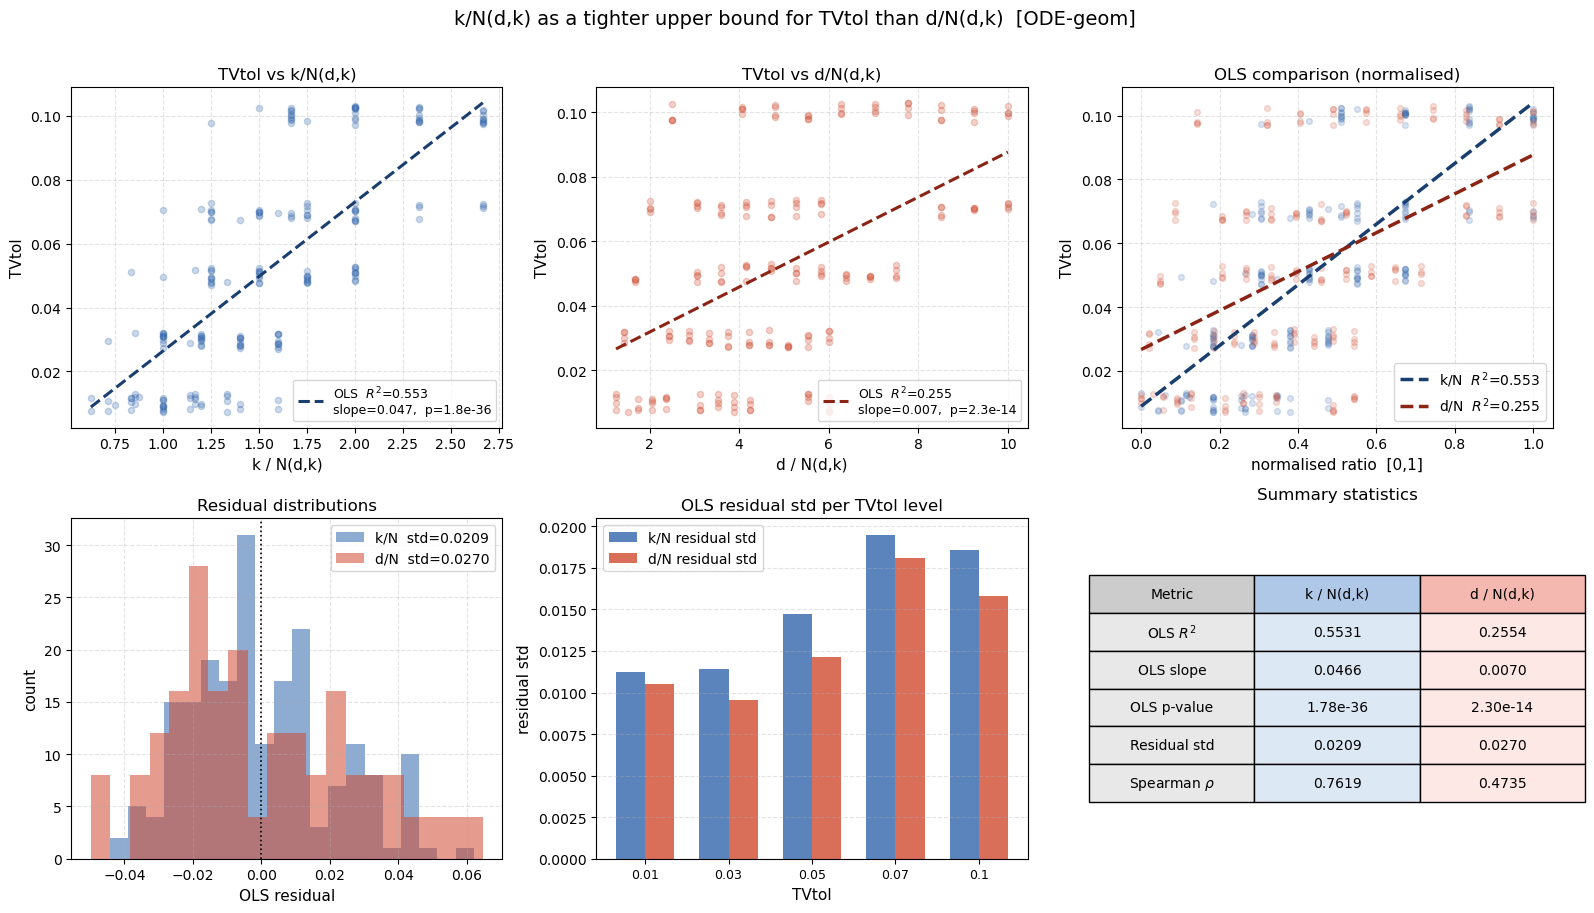

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

COL_K   = "#3266ad"
COL_D   = "#d04a2f"
COL_KLS = "#1a3f6f"
COL_DLS = "#8b2415"

def collect(numerator="k"):
    ratios, tols = [], []
    for tol, data in datasets.items():
        matrix = data[method_key]
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    ratios.append(num / N)
                    tols.append(tol)
    return np.array(ratios), np.array(tols)

rk, tols_k = collect("k")
rd, tols_d = collect("d")

sk, ik, rk_r, pk, _ = linregress(rk, tols_k)
sd, id_, rd_r, pd, _ = linregress(rd, tols_d)

rng = np.random.default_rng(42)

def jitter(arr, scale=0.003):
    return arr + rng.uniform(-scale, scale, size=len(arr))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Panel 1 & 2: scatter + OLS ───────────────────────────────────────────────
for ax, ratios, tols, col, col_ls, num, xlabel in [
    (axes[0,0], rk, tols_k, COL_K, COL_KLS, "k", "k / N(d,k)"),
    (axes[0,1], rd, tols_d, COL_D, COL_DLS, "d", "d / N(d,k)"),
]:
    sl, ic, r_, p_, _ = linregress(ratios, tols)
    x_line = np.linspace(ratios.min(), ratios.max(), 200)

    ax.scatter(ratios, jitter(tols), color=col, alpha=0.25, s=20, zorder=0)
    ax.plot(x_line, sl * x_line + ic, color=col_ls, linewidth=2.2,
            linestyle="--", zorder=3,
            label=f"OLS  $R^2$={r_**2:.3f}\nslope={sl:.3f},  p={p_:.1e}")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("TVtol", fontsize=11)
    ax.set_title(f"TVtol vs {num}/N(d,k)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 3: normalised OLS comparison ───────────────────────────────────────
ax = axes[0, 2]
rk_n = (rk - rk.min()) / (rk.max() - rk.min())
rd_n = (rd - rd.min()) / (rd.max() - rd.min())

ax.scatter(rk_n, jitter(tols_k), color=COL_K, alpha=0.18, s=18, zorder=0)
ax.scatter(rd_n, jitter(tols_d), color=COL_D, alpha=0.18, s=18, zorder=0)

for ratios_n, tols, col, lbl in [
    (rk_n, tols_k, COL_KLS, f"k/N  $R^2$={rk_r**2:.3f}"),
    (rd_n, tols_d, COL_DLS, f"d/N  $R^2$={rd_r**2:.3f}"),
]:
    sl, ic, _, _, _ = linregress(ratios_n, tols)
    x_line = np.linspace(0, 1, 200)
    ax.plot(x_line, sl * x_line + ic, linewidth=2.5, linestyle="--",
            color=col, label=lbl)

ax.set_xlabel("normalised ratio  [0,1]", fontsize=11)
ax.set_ylabel("TVtol", fontsize=11)
ax.set_title("OLS comparison (normalised)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 4: residual distributions ──────────────────────────────────────────
ax = axes[1, 0]
res_k = tols_k - (sk * rk + ik)
res_d = tols_d - (sd * rd + id_)

ax.hist(res_k, bins=20, color=COL_K, alpha=0.55, label=f"k/N  std={res_k.std():.4f}")
ax.hist(res_d, bins=20, color=COL_D, alpha=0.55, label=f"d/N  std={res_d.std():.4f}")
ax.axvline(0, color="black", linewidth=1.2, linestyle=":")
ax.set_xlabel("OLS residual", fontsize=11)
ax.set_ylabel("count", fontsize=11)
ax.set_title("Residual distributions", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 5: residual std per TVtol level ────────────────────────────────────
ax = axes[1, 1]
tol_levels = sorted(datasets.keys())
std_k_per_tol, std_d_per_tol = [], []

for tol in tol_levels:
    mk = tols_k == tol
    md = tols_d == tol
    std_k_per_tol.append(res_k[mk].std() if mk.sum() > 1 else 0)
    std_d_per_tol.append(res_d[md].std() if md.sum() > 1 else 0)

x = np.arange(len(tol_levels))
w = 0.35
ax.bar(x - w/2, std_k_per_tol, width=w, color=COL_K, alpha=0.8, label="k/N residual std")
ax.bar(x + w/2, std_d_per_tol, width=w, color=COL_D, alpha=0.8, label="d/N residual std")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in tol_levels], fontsize=9)
ax.set_xlabel("TVtol", fontsize=11)
ax.set_ylabel("residual std", fontsize=11)
ax.set_title("OLS residual std per TVtol level", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

# ── Panel 6: summary table ────────────────────────────────────────────────────
ax = axes[1, 2]
ax.axis("off")

sp_k, _ = spearmanr(rk, tols_k)
sp_d, _ = spearmanr(rd, tols_d)

rows = [
    ["Metric",               "k / N(d,k)",          "d / N(d,k)"],
    ["OLS $R^2$",            f"{rk_r**2:.4f}",       f"{rd_r**2:.4f}"],
    ["OLS slope",            f"{sk:.4f}",            f"{sd:.4f}"],
    ["OLS p-value",          f"{pk:.2e}",            f"{pd:.2e}"],
    ["Residual std",         f"{res_k.std():.4f}",   f"{res_d.std():.4f}"],
    ["Spearman $\\rho$",     f"{sp_k:.4f}",          f"{sp_d:.4f}"],
]

col_colors = [["#e8e8e8", "#dde8f5", "#fde8e5"]] * len(rows)
col_colors[0] = ["#cccccc", "#b0c8e8", "#f5b8b0"]

tbl = ax.table(cellText=rows, cellLoc="center", loc="center",
               cellColours=col_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 2.1)
ax.set_title("Summary statistics", fontsize=12, pad=14)

fig.suptitle("k/N(d,k) as a tighter upper bound for TVtol than d/N(d,k)  [ODE-geom]",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("kN_vs_dN_upper_bound.pdf", bbox_inches="tight")
plt.show()

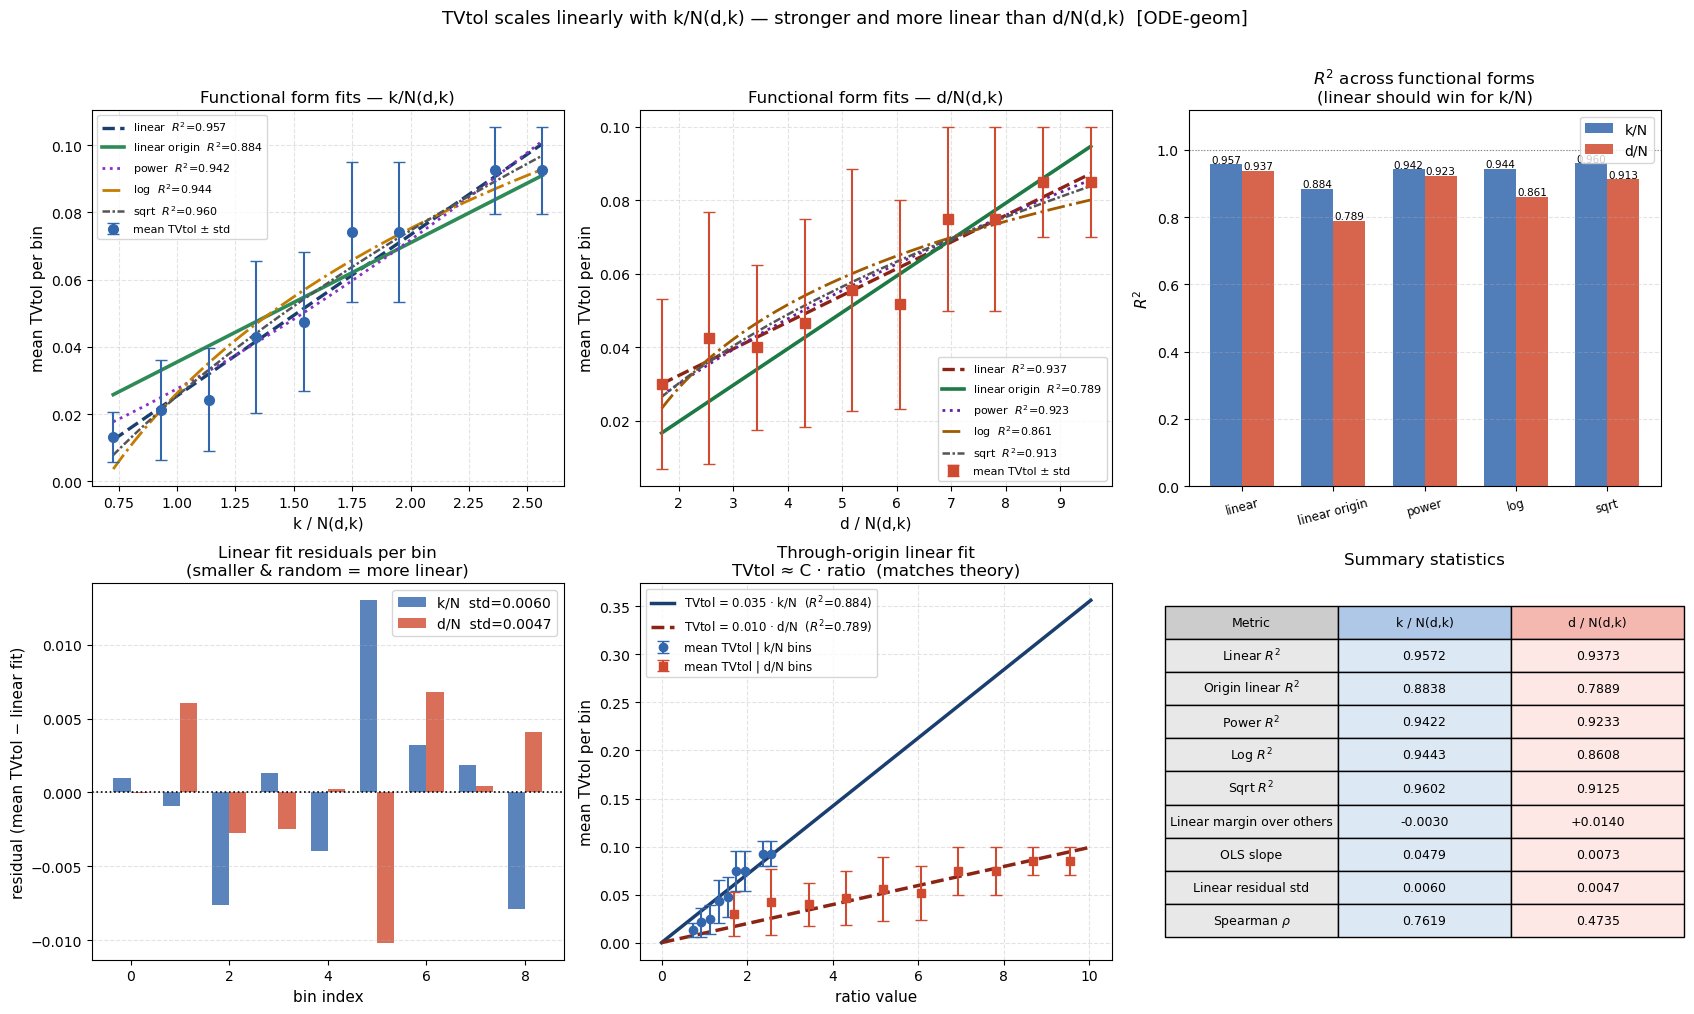

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr, binned_statistic
from scipy.optimize import curve_fit

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

COL_K, COL_KLS = "#3266ad", "#1a3f6f"
COL_D, COL_DLS = "#d04a2f", "#8b2415"

def collect(numerator="k"):
    ratios, tols = [], []
    for tol, data in datasets.items():
        matrix = data[method_key]
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    ratios.append(num / N)
                    tols.append(tol)
    return np.array(ratios), np.array(tols)

def bin_mean(ratios, tols, n_bins=10):
    means, edges, _ = binned_statistic(ratios, tols, statistic="mean", bins=n_bins)
    stds,  _,     _ = binned_statistic(ratios, tols, statistic="std",  bins=n_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    valid   = ~np.isnan(means)
    return centers[valid], means[valid], stds[valid]

rk, tols_k = collect("k")
rd, tols_d = collect("d")

xk, mk, sk_std = bin_mean(rk, tols_k)
xd, md, sd_std = bin_mean(rd, tols_d)

# ── fit multiple functional forms ─────────────────────────────────────────────
def fit_r2(fn, x, y, p0):
    try:
        popt, _ = curve_fit(fn, x, y, p0=p0, maxfev=10000)
        yhat    = fn(x, *popt)
        ss_res  = np.sum((y - yhat) ** 2)
        ss_tot  = np.sum((y - y.mean()) ** 2)
        return popt, 1 - ss_res / ss_tot
    except Exception:
        return None, np.nan

linear  = lambda x, a, b:    a * x + b
origin  = lambda x, a:       a * x           # through origin — matches theory
power   = lambda x, a, b:    a * x ** b
log_fn  = lambda x, a, b:    a * np.log(x) + b
sqrt_fn = lambda x, a, b:    a * np.sqrt(x) + b

forms = {
    "linear":        (linear,  [0.05, 0.0]),
    "linear origin": (origin,  [0.05]),
    "power":         (power,   [0.05, 1.0]),
    "log":           (log_fn,  [0.05, 0.0]),
    "sqrt":          (sqrt_fn, [0.05, 0.0]),
}

fits = {}
for num, (x, m) in [("k", (xk, mk)), ("d", (xd, md))]:
    fits[num] = {}
    for fname, (fn, p0) in forms.items():
        popt, r2 = fit_r2(fn, x, m, p0)
        fits[num][fname] = {"popt": popt, "r2": r2, "fn": fn}

# OLS stats for summary table
sk, ik, rk_r, pk, _ = linregress(xk, mk)
sd, id_, rd_r, pd, _ = linregress(xd, md)
res_k = mk - (sk * xk + ik)
res_d = md - (sd * xd + id_)
sp_k, _ = spearmanr(rk, tols_k)
sp_d, _ = spearmanr(rd, tols_d)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

fit_styles = {
    "linear":        ("--",  2.4, "#1a3f6f"),
    "linear origin": ("-",   2.6, "#2e8b57"),
    "power":         (":",   2.0, "#8b2fc9"),
    "log":           ("-.",  2.0, "#c47d00"),
    "sqrt":          ((0,(3,1,1,1)), 1.8, "#555555"),
}

# ── Panel 1: all fits for k/N ─────────────────────────────────────────────────
ax = axes[0, 0]
ax.errorbar(xk, mk, yerr=sk_std, fmt="o", color=COL_K, markersize=7,
            capsize=4, zorder=5, label="mean TVtol ± std")
x_line = np.linspace(xk.min(), xk.max(), 300)
for fname, (ls, lw, fc) in fit_styles.items():
    f = fits["k"][fname]
    if f["popt"] is not None:
        ax.plot(x_line, f["fn"](x_line, *f["popt"]),
                linestyle=ls, linewidth=lw, color=fc,
                label=f"{fname}  $R^2$={f['r2']:.3f}")
ax.set_xlabel("k / N(d,k)", fontsize=11)
ax.set_ylabel("mean TVtol per bin", fontsize=11)
ax.set_title("Functional form fits — k/N(d,k)", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 2: all fits for d/N ─────────────────────────────────────────────────
fit_styles_d = {
    "linear":        ("--",  2.4, "#8b2415"),
    "linear origin": ("-",   2.6, "#1d7a45"),
    "power":         (":",   2.0, "#6b1fa0"),
    "log":           ("-.",  2.0, "#a05a00"),
    "sqrt":          ((0,(3,1,1,1)), 1.8, "#555555"),
}
ax = axes[0, 1]
ax.errorbar(xd, md, yerr=sd_std, fmt="s", color=COL_D, markersize=7,
            capsize=4, zorder=5, label="mean TVtol ± std")
x_line_d = np.linspace(xd.min(), xd.max(), 300)
for fname, (ls, lw, fc) in fit_styles_d.items():
    f = fits["d"][fname]
    if f["popt"] is not None:
        ax.plot(x_line_d, f["fn"](x_line_d, *f["popt"]),
                linestyle=ls, linewidth=lw, color=fc,
                label=f"{fname}  $R^2$={f['r2']:.3f}")
ax.set_xlabel("d / N(d,k)", fontsize=11)
ax.set_ylabel("mean TVtol per bin", fontsize=11)
ax.set_title("Functional form fits — d/N(d,k)", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 3: R² comparison across functional forms ───────────────────────────
ax = axes[0, 2]
fnames = list(forms.keys())
r2_k   = [fits["k"][f]["r2"] for f in fnames]
r2_d   = [fits["d"][f]["r2"] for f in fnames]

x      = np.arange(len(fnames))
w      = 0.35
bars_k = ax.bar(x - w/2, r2_k, width=w, color=COL_K, alpha=0.85, label="k/N")
bars_d = ax.bar(x + w/2, r2_d, width=w, color=COL_D, alpha=0.85, label="d/N")
for bar, v in [(b, v) for bars, vals in [(bars_k, r2_k), (bars_d, r2_d)]
               for b, v in zip(bars, vals)]:
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(fnames, fontsize=8.5, rotation=15)
ax.set_ylabel("$R^2$", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("$R^2$ across functional forms\n(linear should win for k/N)", fontsize=12)
ax.legend(fontsize=10)
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":")
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

# ── Panel 4: linearity check — residuals of linear fit ───────────────────────
ax = axes[1, 0]
w = 0.35
x_idx = np.arange(len(xk))
ax.bar(x_idx - w/2, res_k, width=w, color=COL_K, alpha=0.8,
       label=f"k/N  std={res_k.std():.4f}")
ax.bar(x_idx + w/2, res_d[:len(x_idx)], width=w, color=COL_D, alpha=0.8,
       label=f"d/N  std={res_d.std():.4f}")
ax.axhline(0, color="black", linewidth=1.2, linestyle=":")
ax.set_xlabel("bin index", fontsize=11)
ax.set_ylabel("residual (mean TVtol − linear fit)", fontsize=11)
ax.set_title("Linear fit residuals per bin\n(smaller & random = more linear)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

# ── Panel 5: linearity origin fit — TVtol ≈ C·k/N ────────────────────────────
ax = axes[1, 1]
C_k = fits["k"]["linear origin"]["popt"][0]
C_d = fits["d"]["linear origin"]["popt"][0]

ax.errorbar(xk, mk, yerr=sk_std, fmt="o", color=COL_K, markersize=6,
            capsize=4, zorder=4, label="mean TVtol | k/N bins")
ax.errorbar(xd, md, yerr=sd_std, fmt="s", color=COL_D, markersize=6,
            capsize=4, zorder=4, label="mean TVtol | d/N bins")

x_full = np.linspace(0, max(xk.max(), xd.max()) * 1.05, 300)
ax.plot(x_full, C_k * x_full, color=COL_KLS, linewidth=2.5, linestyle="-",
        label=f"TVtol = {C_k:.3f} · k/N  ($R^2$={fits['k']['linear origin']['r2']:.3f})")
ax.plot(x_full, C_d * x_full, color=COL_DLS, linewidth=2.5, linestyle="--",
        label=f"TVtol = {C_d:.3f} · d/N  ($R^2$={fits['d']['linear origin']['r2']:.3f})")
ax.set_xlabel("ratio value", fontsize=11)
ax.set_ylabel("mean TVtol per bin", fontsize=11)
ax.set_title("Through-origin linear fit\nTVtol ≈ C · ratio  (matches theory)", fontsize=12)
ax.legend(fontsize=8.5)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 6: summary table ────────────────────────────────────────────────────
ax = axes[1, 2]
ax.axis("off")

lin_gap_k = fits["k"]["linear"]["r2"] - max(
    fits["k"]["power"]["r2"], fits["k"]["log"]["r2"], fits["k"]["sqrt"]["r2"])
lin_gap_d = fits["d"]["linear"]["r2"] - max(
    fits["d"]["power"]["r2"], fits["d"]["log"]["r2"], fits["d"]["sqrt"]["r2"])

rows = [
    ["Metric",                      "k / N(d,k)",                                   "d / N(d,k)"],
    ["Linear $R^2$",                f"{fits['k']['linear']['r2']:.4f}",              f"{fits['d']['linear']['r2']:.4f}"],
    ["Origin linear $R^2$",         f"{fits['k']['linear origin']['r2']:.4f}",       f"{fits['d']['linear origin']['r2']:.4f}"],
    ["Power $R^2$",                 f"{fits['k']['power']['r2']:.4f}",               f"{fits['d']['power']['r2']:.4f}"],
    ["Log $R^2$",                   f"{fits['k']['log']['r2']:.4f}",                 f"{fits['d']['log']['r2']:.4f}"],
    ["Sqrt $R^2$",                  f"{fits['k']['sqrt']['r2']:.4f}",                f"{fits['d']['sqrt']['r2']:.4f}"],
    ["Linear margin over others",   f"{lin_gap_k:+.4f}",                            f"{lin_gap_d:+.4f}"],
    ["OLS slope",                   f"{sk:.4f}",                                     f"{sd:.4f}"],
    ["Linear residual std",         f"{res_k.std():.4f}",                            f"{res_d.std():.4f}"],
    ["Spearman $\\rho$",            f"{sp_k:.4f}",                                   f"{sp_d:.4f}"],
]

col_colors = [["#e8e8e8", "#dde8f5", "#fde8e5"]] * len(rows)
col_colors[0] = ["#cccccc", "#b0c8e8", "#f5b8b0"]

tbl = ax.table(cellText=rows, cellLoc="center", loc="center",
               cellColours=col_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.85)
ax.set_title("Summary statistics", fontsize=12, pad=14)

fig.suptitle(
    "TVtol scales linearly with k/N(d,k) — stronger and more linear than d/N(d,k)  [ODE-geom]",
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("linearity_kN_vs_dN.pdf", bbox_inches="tight")
plt.show()

Metric                                k/N        d/N
----------------------------------------------------
Estimated C                        0.0425     0.0178
Mean utilisation                   0.7353     0.6478
Mean slack                         0.2647     0.3522
Std of slack                       0.1913     0.1678
Min utilisation                    0.4315     0.4794


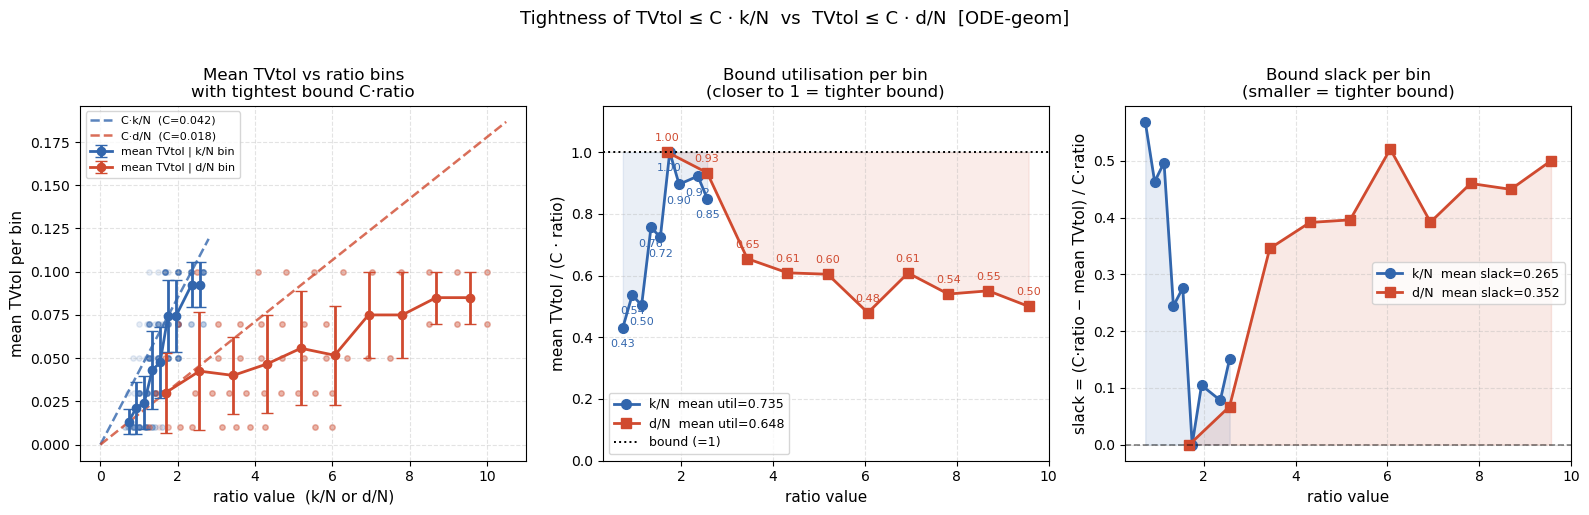

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, linregress

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

COL_K, COL_D = "#3266ad", "#d04a2f"

def collect(numerator="k"):
    ratios, tols = [], []
    for tol, data in datasets.items():
        matrix = data[method_key]
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    ratios.append(num / N)
                    tols.append(tol)
    return np.array(ratios), np.array(tols)

rk, tols_k = collect("k")
rd, tols_d = collect("d")

def bin_mean_tol(ratios, tols, n_bins=10):
    """Mean TVtol per bin of ratio values, plus std and counts."""
    means, edges, _  = binned_statistic(ratios, tols, statistic="mean", bins=n_bins)
    stds,  _,     _  = binned_statistic(ratios, tols, statistic="std",  bins=n_bins)
    counts, _,    _  = binned_statistic(ratios, tols, statistic="count",bins=n_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    valid   = ~np.isnan(means) & (counts >= 2)
    return centers[valid], means[valid], stds[valid], edges

xk, mk, sk, ek = bin_mean_tol(rk, tols_k)
xd, md, sd, ed = bin_mean_tol(rd, tols_d)

# ── tightest valid C: max(mean_TVtol / ratio) over bins ──────────────────────
C_k = np.max(mk / xk)
C_d = np.max(md / xd)

# ── slack per bin: (C*ratio - mean_TVtol) / (C*ratio) ────────────────────────
slack_k = (C_k * xk - mk) / (C_k * xk)
slack_d = (C_d * xd - md) / (C_d * xd)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: mean TVtol vs ratio, with bound line ─────────────────────────────
ax = axes[0]
for ratios, tols, x, m, s, C, col, lbl, num in [
    (rk, tols_k, xk, mk, sk, C_k, COL_K, "k/N", "k"),
    (rd, tols_d, xd, md, sd, C_d, COL_D, "d/N", "d"),
]:
    # raw scatter
    ax.scatter(ratios, tols, color=col, alpha=0.12, s=15, zorder=0)
    # binned mean ± std
    ax.errorbar(x, m, yerr=s, fmt="o-", color=col, linewidth=2,
                markersize=6, capsize=4, zorder=3,
                label=f"mean TVtol | {lbl} bin")
    # bound line through origin
    x_line = np.linspace(0, ratios.max() * 1.05, 200)
    ax.plot(x_line, C * x_line, color=col, linewidth=1.8,
            linestyle="--", alpha=0.8,
            label=f"C·{lbl}  (C={C:.3f})")

ax.set_xlabel("ratio value  (k/N or d/N)", fontsize=11)
ax.set_ylabel("mean TVtol per bin", fontsize=11)
ax.set_title("Mean TVtol vs ratio bins\nwith tightest bound C·ratio", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 2: mean TVtol / (C·ratio) per bin — should be ≤ 1, close to 1 ──────
ax = axes[1]
utilisation_k = mk / (C_k * xk)   # how much of the bound is used; 1 = perfectly tight
utilisation_d = md / (C_d * xd)

ax.plot(xk, utilisation_k, "o-", color=COL_K, linewidth=2, markersize=7,
        label=f"k/N  mean util={utilisation_k.mean():.3f}")
ax.plot(xd, utilisation_d, "s-", color=COL_D, linewidth=2, markersize=7,
        label=f"d/N  mean util={utilisation_d.mean():.3f}")
ax.axhline(1.0, color="black", linewidth=1.4, linestyle=":",
           label="bound (=1)")
ax.fill_between(xk, utilisation_k, 1.0, alpha=0.10, color=COL_K)
ax.fill_between(xd, utilisation_d, 1.0, alpha=0.10, color=COL_D)

# annotate each point
for x_, u in zip(xk, utilisation_k):
    ax.annotate(f"{u:.2f}", (x_, u), textcoords="offset points",
                xytext=(0, -14), ha="center", fontsize=8, color=COL_K)
for x_, u in zip(xd, utilisation_d):
    ax.annotate(f"{u:.2f}", (x_, u), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=COL_D)

ax.set_xlabel("ratio value", fontsize=11)
ax.set_ylabel("mean TVtol / (C · ratio)", fontsize=11)
ax.set_title("Bound utilisation per bin\n(closer to 1 = tighter bound)", fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 3: slack per bin ────────────────────────────────────────────────────
ax = axes[2]
w = (xk[1] - xk[0]) * 0.4 if len(xk) > 1 else 0.05

# use scatter+line since bin centers differ between k and d
ax.plot(xk, slack_k, "o-", color=COL_K, linewidth=2, markersize=7,
        label=f"k/N  mean slack={slack_k.mean():.3f}")
ax.plot(xd, slack_d, "s-", color=COL_D, linewidth=2, markersize=7,
        label=f"d/N  mean slack={slack_d.mean():.3f}")
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
ax.fill_between(xk, 0, slack_k, alpha=0.12, color=COL_K)
ax.fill_between(xd, 0, slack_d, alpha=0.12, color=COL_D)

ax.set_xlabel("ratio value", fontsize=11)
ax.set_ylabel("slack = (C·ratio − mean TVtol) / C·ratio", fontsize=11)
ax.set_title("Bound slack per bin\n(smaller = tighter bound)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.35)

# ── summary printout ──────────────────────────────────────────────────────────
print(f"{'Metric':<30} {'k/N':>10} {'d/N':>10}")
print("-" * 52)
print(f"{'Estimated C':<30} {C_k:>10.4f} {C_d:>10.4f}")
print(f"{'Mean utilisation':<30} {utilisation_k.mean():>10.4f} {utilisation_d.mean():>10.4f}")
print(f"{'Mean slack':<30} {slack_k.mean():>10.4f} {slack_d.mean():>10.4f}")
print(f"{'Std of slack':<30} {slack_k.std():>10.4f} {slack_d.std():>10.4f}")
print(f"{'Min utilisation':<30} {utilisation_k.min():>10.4f} {utilisation_d.min():>10.4f}")

fig.suptitle("Tightness of TVtol ≤ C · k/N  vs  TVtol ≤ C · d/N  [ODE-geom]",
             fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig("bound_tightness_binned.pdf", bbox_inches="tight")
plt.show()

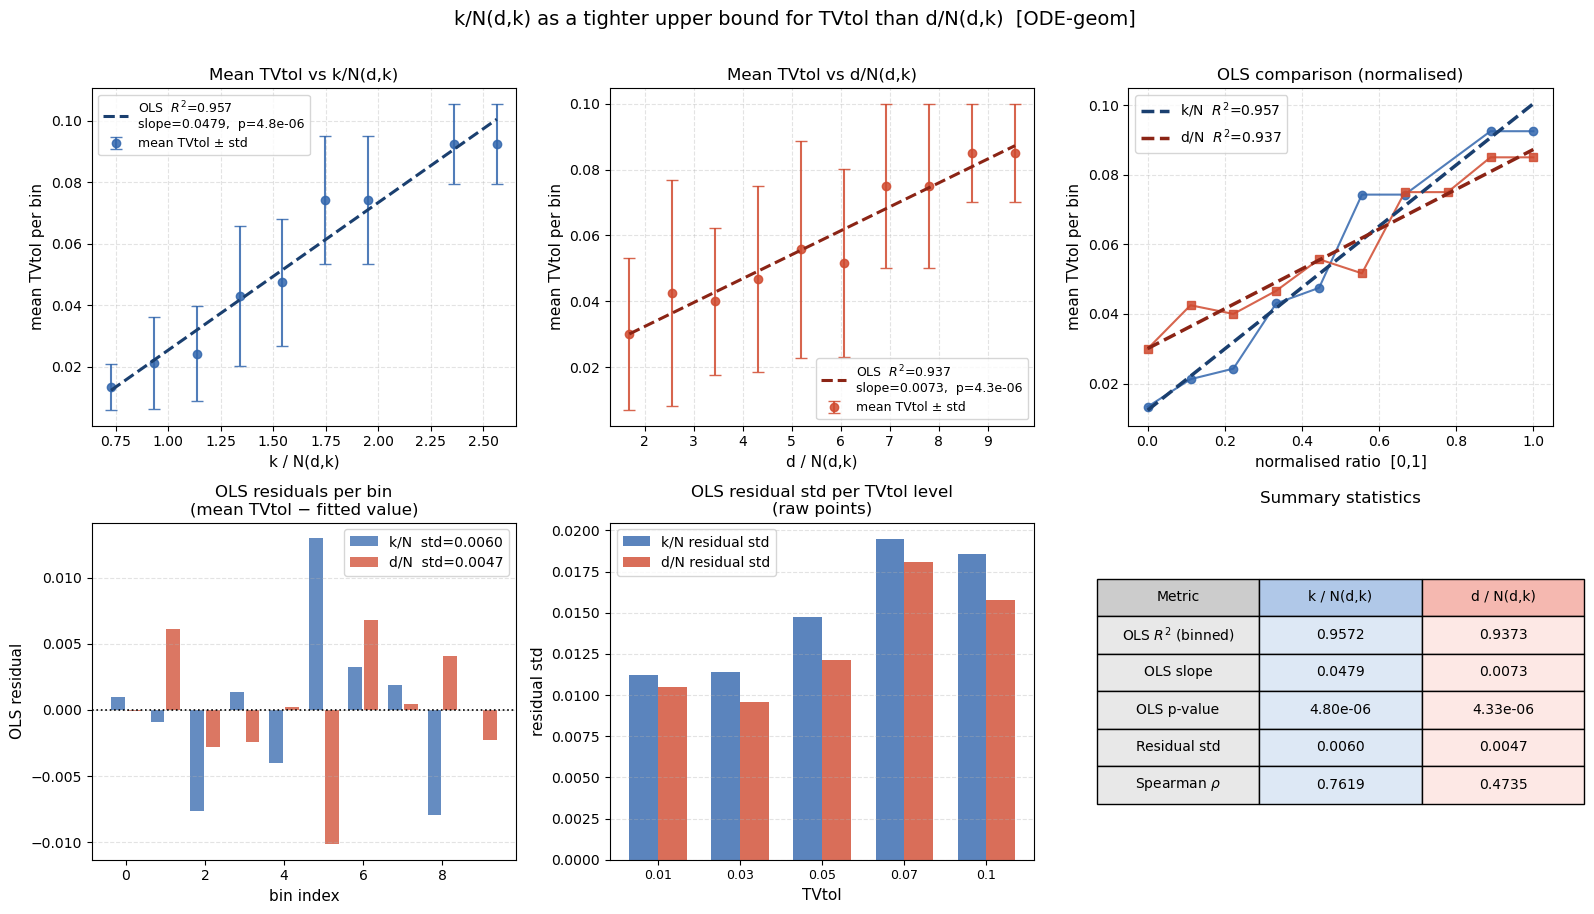

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr, binned_statistic

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

COL_K, COL_KLS = "#3266ad", "#1a3f6f"
COL_D, COL_DLS = "#d04a2f", "#8b2415"

def collect(numerator="k"):
    ratios, tols = [], []
    for tol, data in datasets.items():
        matrix = data[method_key]
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    ratios.append(num / N)
                    tols.append(tol)
    return np.array(ratios), np.array(tols)

def bin_mean(ratios, tols, n_bins=10):
    means, edges, _ = binned_statistic(ratios, tols, statistic="mean", bins=n_bins)
    stds,  _,     _ = binned_statistic(ratios, tols, statistic="std",  bins=n_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    valid   = ~np.isnan(means)
    return centers[valid], means[valid], stds[valid]

rk, tols_k = collect("k")
rd, tols_d = collect("d")

# binned means — used for plotting
xk, mk, sk_std = bin_mean(rk, tols_k)
xd, md, sd_std = bin_mean(rd, tols_d)

# OLS on binned means — regression on the aggregated signal
sk, ik, rk_r, pk, _ = linregress(xk, mk)
sd, id_, rd_r, pd, _ = linregress(xd, md)

# residuals from OLS (on binned means)
res_k = mk - (sk * xk + ik)
res_d = md - (sd * xd + id_)

# spearman on raw points (rank correlation of the underlying data)
sp_k, _ = spearmanr(rk, tols_k)
sp_d, _ = spearmanr(rd, tols_d)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Panel 1 & 2: binned mean TVtol + OLS ─────────────────────────────────────
for ax, x, m, s, col, col_ls, num, xlabel in [
    (axes[0,0], xk, mk, sk_std, COL_K, COL_KLS, "k", "k / N(d,k)"),
    (axes[0,1], xd, md, sd_std, COL_D, COL_DLS, "d", "d / N(d,k)"),
]:
    sl, ic, r_, p_, _ = linregress(x, m)
    x_line = np.linspace(x.min(), x.max(), 200)

    ax.errorbar(x, m, yerr=s, fmt="o", color=col, markersize=6,
                capsize=4, alpha=0.85, zorder=2, label="mean TVtol ± std")
    ax.plot(x_line, sl * x_line + ic, color=col_ls, linewidth=2.2,
            linestyle="--", zorder=3,
            label=f"OLS  $R^2$={r_**2:.3f}\nslope={sl:.4f},  p={p_:.1e}")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("mean TVtol per bin", fontsize=11)
    ax.set_title(f"Mean TVtol vs {num}/N(d,k)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 3: normalised OLS comparison on same axes ──────────────────────────
ax = axes[0, 2]
xk_n = (xk - xk.min()) / (xk.max() - xk.min())
xd_n = (xd - xd.min()) / (xd.max() - xd.min())

ax.plot(xk_n, mk, "o-", color=COL_K, markersize=6, alpha=0.85,
        linewidth=1.5, label="_nolegend_")
ax.plot(xd_n, md, "s-", color=COL_D, markersize=6, alpha=0.85,
        linewidth=1.5, label="_nolegend_")

for x_n, m, col, lbl in [
    (xk_n, mk, COL_KLS, f"k/N  $R^2$={rk_r**2:.3f}"),
    (xd_n, md, COL_DLS, f"d/N  $R^2$={rd_r**2:.3f}"),
]:
    sl, ic, _, _, _ = linregress(x_n, m)
    x_line = np.linspace(0, 1, 200)
    ax.plot(x_line, sl * x_line + ic, linewidth=2.5,
            linestyle="--", color=col, label=lbl)

ax.set_xlabel("normalised ratio  [0,1]", fontsize=11)
ax.set_ylabel("mean TVtol per bin", fontsize=11)
ax.set_title("OLS comparison (normalised)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35)

# ── Panel 4: residual distributions ──────────────────────────────────────────
ax = axes[1, 0]
ax.bar(np.arange(len(res_k)) - 0.2, res_k, width=0.35,
       color=COL_K, alpha=0.75, label=f"k/N  std={res_k.std():.4f}")
ax.bar(np.arange(len(res_d)) + 0.2, res_d, width=0.35,
       color=COL_D, alpha=0.75, label=f"d/N  std={res_d.std():.4f}")
ax.axhline(0, color="black", linewidth=1.2, linestyle=":")
ax.set_xlabel("bin index", fontsize=11)
ax.set_ylabel("OLS residual", fontsize=11)
ax.set_title("OLS residuals per bin\n(mean TVtol − fitted value)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

# ── Panel 5: residual std per TVtol level ─────────────────────────────────────
# computed on raw points per tol level for a fair per-level comparison
ax = axes[1, 1]
tol_levels = sorted(datasets.keys())
std_k_per_tol, std_d_per_tol = [], []

sk_raw, ik_raw, _, _, _ = linregress(rk, tols_k)
sd_raw, id_raw, _, _, _ = linregress(rd, tols_d)
res_k_raw = tols_k - (sk_raw * rk + ik_raw)
res_d_raw = tols_d - (sd_raw * rd + id_raw)

for tol in tol_levels:
    mk_ = tols_k == tol
    md_ = tols_d == tol
    std_k_per_tol.append(res_k_raw[mk_].std() if mk_.sum() > 1 else 0)
    std_d_per_tol.append(res_d_raw[md_].std() if md_.sum() > 1 else 0)

x = np.arange(len(tol_levels))
w = 0.35
ax.bar(x - w/2, std_k_per_tol, width=w, color=COL_K, alpha=0.8,
       label="k/N residual std")
ax.bar(x + w/2, std_d_per_tol, width=w, color=COL_D, alpha=0.8,
       label="d/N residual std")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in tol_levels], fontsize=9)
ax.set_xlabel("TVtol", fontsize=11)
ax.set_ylabel("residual std", fontsize=11)
ax.set_title("OLS residual std per TVtol level\n(raw points)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

# ── Panel 6: summary table ────────────────────────────────────────────────────
ax = axes[1, 2]
ax.axis("off")

rows = [
    ["Metric",             "k / N(d,k)",          "d / N(d,k)"],
    ["OLS $R^2$ (binned)", f"{rk_r**2:.4f}",       f"{rd_r**2:.4f}"],
    ["OLS slope",          f"{sk:.4f}",             f"{sd:.4f}"],
    ["OLS p-value",        f"{pk:.2e}",             f"{pd:.2e}"],
    ["Residual std",       f"{res_k.std():.4f}",    f"{res_d.std():.4f}"],
    ["Spearman $\\rho$",   f"{sp_k:.4f}",           f"{sp_d:.4f}"],
]

col_colors = [["#e8e8e8", "#dde8f5", "#fde8e5"]] * len(rows)
col_colors[0] = ["#cccccc", "#b0c8e8", "#f5b8b0"]

tbl = ax.table(cellText=rows, cellLoc="center", loc="center",
               cellColours=col_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 2.1)
ax.set_title("Summary statistics", fontsize=12, pad=14)

fig.suptitle("k/N(d,k) as a tighter upper bound for TVtol than d/N(d,k)  [ODE-geom]",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("kN_vs_dN_upper_bound.pdf", bbox_inches="tight")
plt.show()

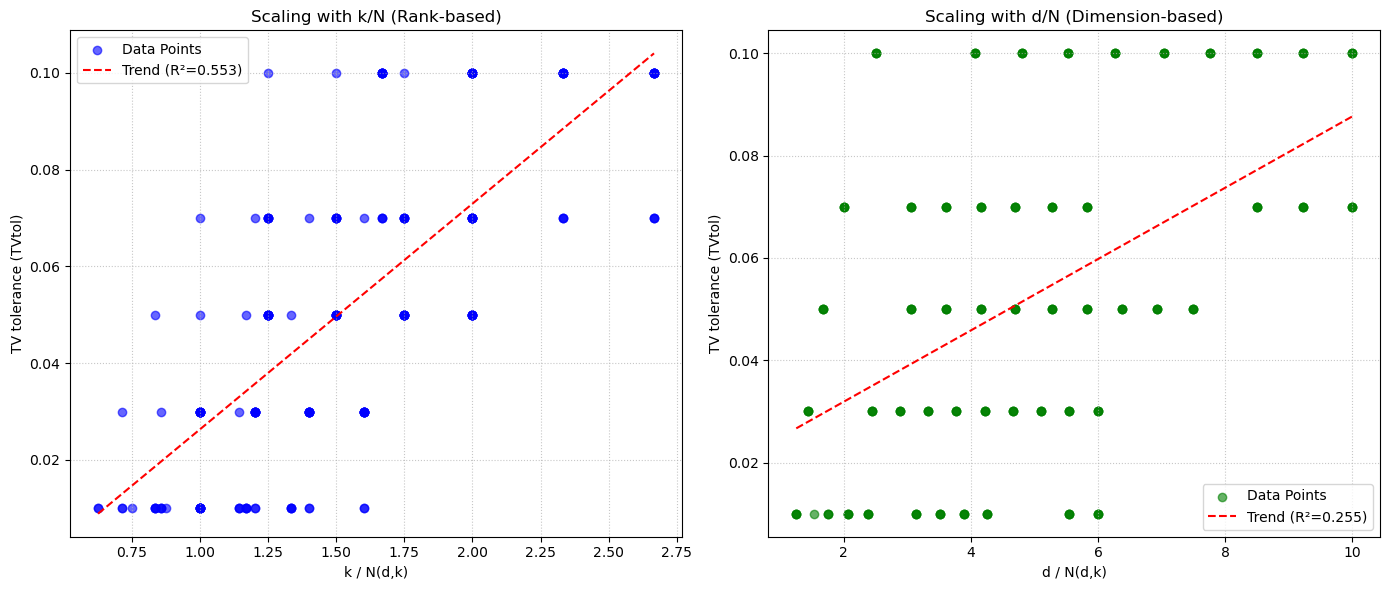

R-squared for k/N: 0.5531
R-squared for d/N: 0.2554


In [90]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Setup parameters as defined in your request
tols = [0.01, 0.03, 0.05, 0.07, 0.1]
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS = [int(i) for i in np.linspace(50, 80, num=4)]

# Lists to store the data points
k_ratio_data = [] # (k/N)
d_ratio_data = [] # (d/N)
y_tols_k = []
y_tols_d = []

# Load data from the 5 files
for tol in tols:
    file_path = f"assets/N_matrix_TVtol_{tol}_low_rank_Gaussian_TV_results.json"
    with open(file_path, "r") as f:
        data = json.load(f)
    
    # Extract the relevant matrix
    # Assuming rows are indexed by DIMENSIONS and columns by RANKS
    matrix = data['N_ode_geom_matrix']
    
    for i, d in enumerate(DIMENSIONS):
        for j, k in enumerate(RANKS):
            N_val = matrix[i][j]
            
            # Handle potential infinity or zero values
            if N_val != float('inf') and N_val > 0:
                k_ratio_data.append(k / N_val)
                d_ratio_data.append(d / N_val)
                y_tols_k.append(tol)
                y_tols_d.append(tol)

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: TVtol vs k/N
ax1.scatter(k_ratio_data, y_tols_k, alpha=0.6, label='Data Points', color='blue')
# Calculate linear regression for trend
slope_k, intercept_k, r_value_k, _, _ = linregress(k_ratio_data, y_tols_k)
line_k = [slope_k * x + intercept_k for x in k_ratio_data]
ax1.plot(k_ratio_data, line_k, color='red', linestyle='--', label=f'Trend (R²={r_value_k**2:.3f})')
ax1.set_xlabel('k / N(d,k)')
ax1.set_ylabel('TV tolerance (TVtol)')
ax1.set_title('Scaling with k/N (Rank-based)')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: TVtol vs d/N
ax2.scatter(d_ratio_data, y_tols_d, alpha=0.6, label='Data Points', color='green')
# Calculate linear regression for trend
slope_d, intercept_d, r_value_d, _, _ = linregress(d_ratio_data, y_tols_d)
line_d = [slope_d * x + intercept_d for x in d_ratio_data]
ax2.plot(d_ratio_data, line_d, color='red', linestyle='--', label=f'Trend (R²={r_value_d**2:.3f})')
ax2.set_xlabel('d / N(d,k)')
ax2.set_ylabel('TV tolerance (TVtol)')
ax2.set_title('Scaling with d/N (Dimension-based)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"R-squared for k/N: {r_value_k**2:.4f}")
print(f"R-squared for d/N: {r_value_d**2:.4f}")

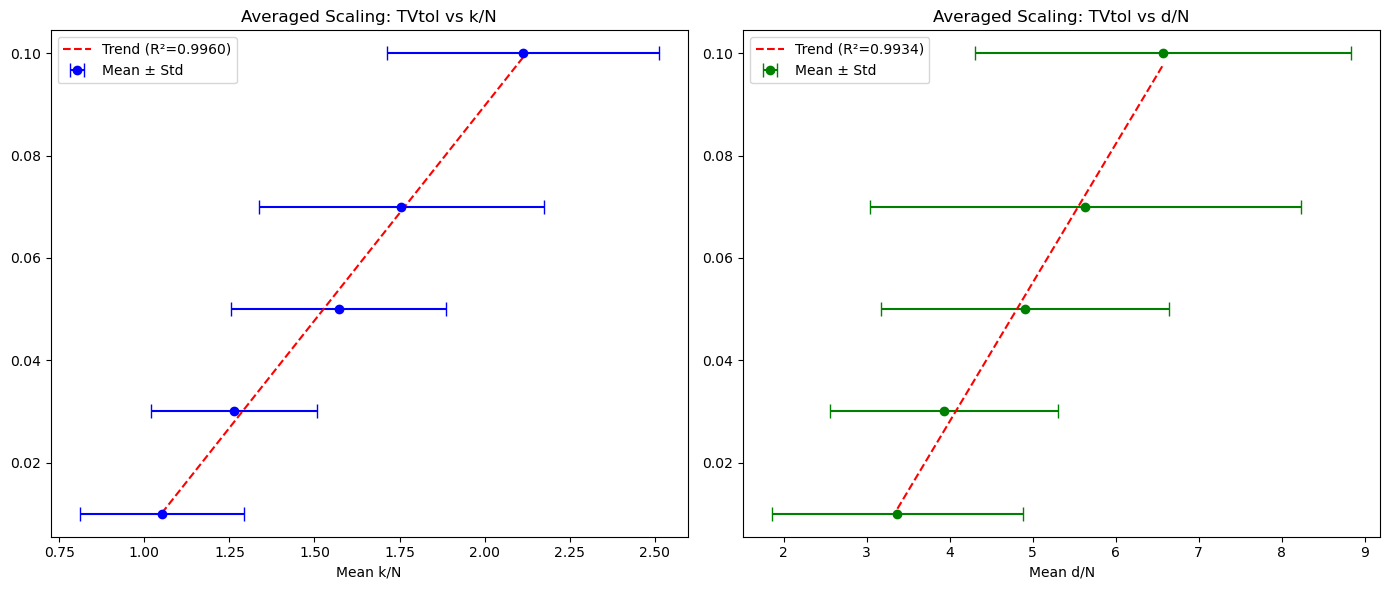

In [91]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Parameters
tols = [0.01, 0.03, 0.05, 0.07, 0.1]
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS = [int(i) for i in np.linspace(50, 80, num=4)]

# Lists to store aggregated statistics
summary = {'tv_tol': [], 'mean_k_n': [], 'std_k_n': [], 'mean_d_n': [], 'std_d_n': []}

for tol in tols:
    file_path = f"assets/N_matrix_TVtol_{tol}_low_rank_Gaussian_TV_results.json"
    with open(file_path, "r") as f:
        data = json.load(f)
    
    matrix = data['N_ode_geom_matrix']
    k_ratios, d_ratios = [], []
    
    for i, d in enumerate(DIMENSIONS):
        for j, k in enumerate(RANKS):
            N_val = matrix[i][j]
            if N_val != float('inf') and N_val > 0:
                k_ratios.append(k / N_val)
                d_ratios.append(d / N_val)
    
    if k_ratios:
        summary['tv_tol'].append(tol)
        summary['mean_k_n'].append(np.mean(k_ratios))
        summary['std_k_n'].append(np.std(k_ratios))
        summary['mean_d_n'].append(np.mean(d_ratios))
        summary['std_d_n'].append(np.std(d_ratios))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: TVtol vs Mean(k/N)
ax1.errorbar(summary['mean_k_n'], summary['tv_tol'], xerr=summary['std_k_n'], 
             fmt='o', capsize=5, label='Mean ± Std', color='blue')
slope_k, intercept_k, r_k, _, _ = linregress(summary['mean_k_n'], summary['tv_tol'])
ax1.plot(summary['mean_k_n'], [slope_k*x + intercept_k for x in summary['mean_k_n']], 
         'r--', label=f'Trend (R²={r_k**2:.4f})')
ax1.set_title('Averaged Scaling: TVtol vs k/N')
ax1.set_xlabel('Mean k/N')
ax1.legend()

# Plot 2: TVtol vs Mean(d/N)
ax2.errorbar(summary['mean_d_n'], summary['tv_tol'], xerr=summary['std_d_n'], 
             fmt='o', capsize=5, label='Mean ± Std', color='green')
slope_d, intercept_d, r_d, _, _ = linregress(summary['mean_d_n'], summary['tv_tol'])
ax2.plot(summary['mean_d_n'], [slope_d*x + intercept_d for x in summary['mean_d_n']], 
         'r--', label=f'Trend (R²={r_d**2:.4f})')
ax2.set_title('Averaged Scaling: TVtol vs d/N')
ax2.set_xlabel('Mean d/N')
ax2.legend()

plt.tight_layout()
plt.show()

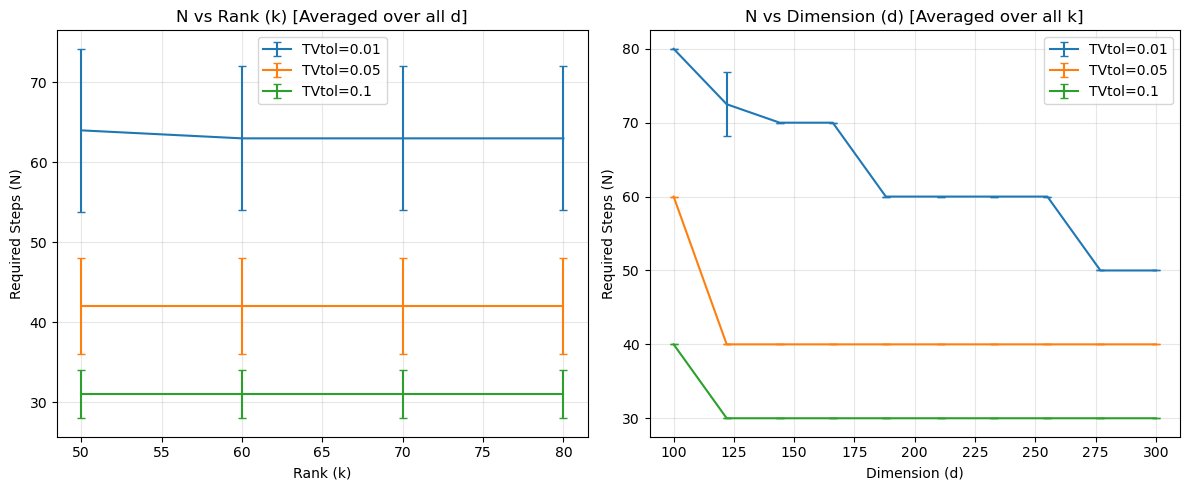

In [92]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Parameters
tols = [0.01, 0.05, 0.1] # Selected to keep plot clean
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS = [int(i) for i in np.linspace(50, 80, num=4)]

plt.figure(figsize=(12, 5))

# Comparison 1: Does N scale with k regardless of d?
plt.subplot(1, 2, 1)
for tol in tols:
    file = f"assets/N_matrix_TVtol_{tol}_low_rank_Gaussian_TV_results.json"
    with open(file, "r") as f:
        matrix = np.array(json.load(f)['N_ode_geom_matrix'])
    
    # Average N across all dimensions d for each rank k
    mean_N_per_k = np.mean(matrix, axis=0) 
    std_N_per_k = np.std(matrix, axis=0)
    
    plt.errorbar(RANKS, mean_N_per_k, yerr=std_N_per_k, label=f'TVtol={tol}', capsize=3)

plt.title("N vs Rank (k) [Averaged over all d]")
plt.xlabel("Rank (k)")
plt.ylabel("Required Steps (N)")
plt.legend()
plt.grid(True, alpha=0.3)

# Comparison 2: Does N scale with d regardless of k?
plt.subplot(1, 2, 2)
for tol in tols:
    file = f"assets/N_matrix_TVtol_{tol}_low_rank_Gaussian_TV_results.json"
    with open(file, "r") as f:
        matrix = np.array(json.load(f)['N_ode_geom_matrix'])
    
    # Average N across all ranks k for each dimension d
    mean_N_per_d = np.mean(matrix, axis=1)
    std_N_per_d = np.std(matrix, axis=1)
    
    plt.errorbar(DIMENSIONS, mean_N_per_d, yerr=std_N_per_d, label=f'TVtol={tol}', capsize=3)

plt.title("N vs Dimension (d) [Averaged over all k]")
plt.xlabel("Dimension (d)")
plt.ylabel("Required Steps (N)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Few other plots

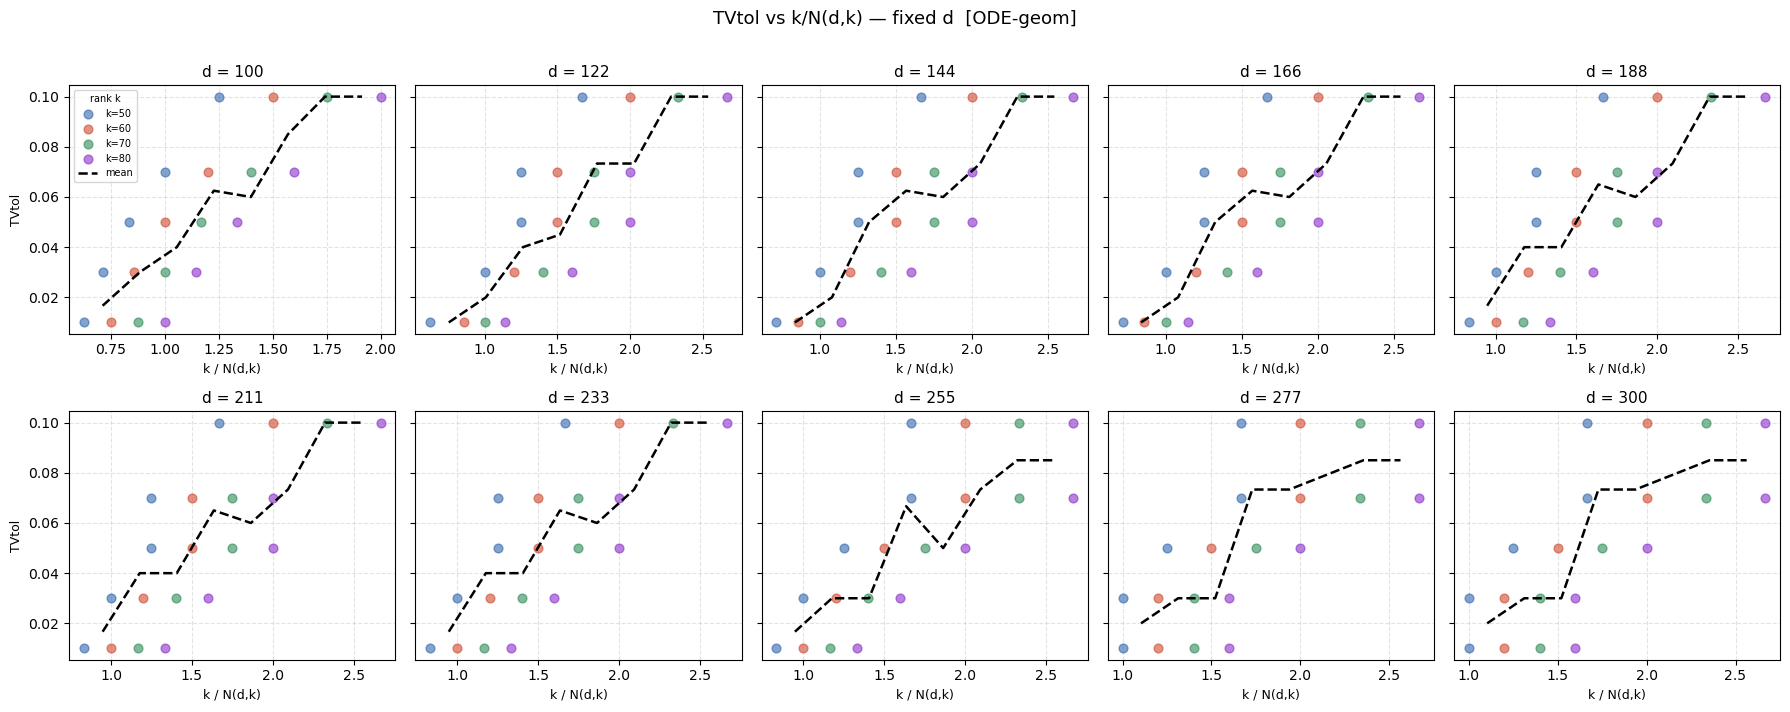

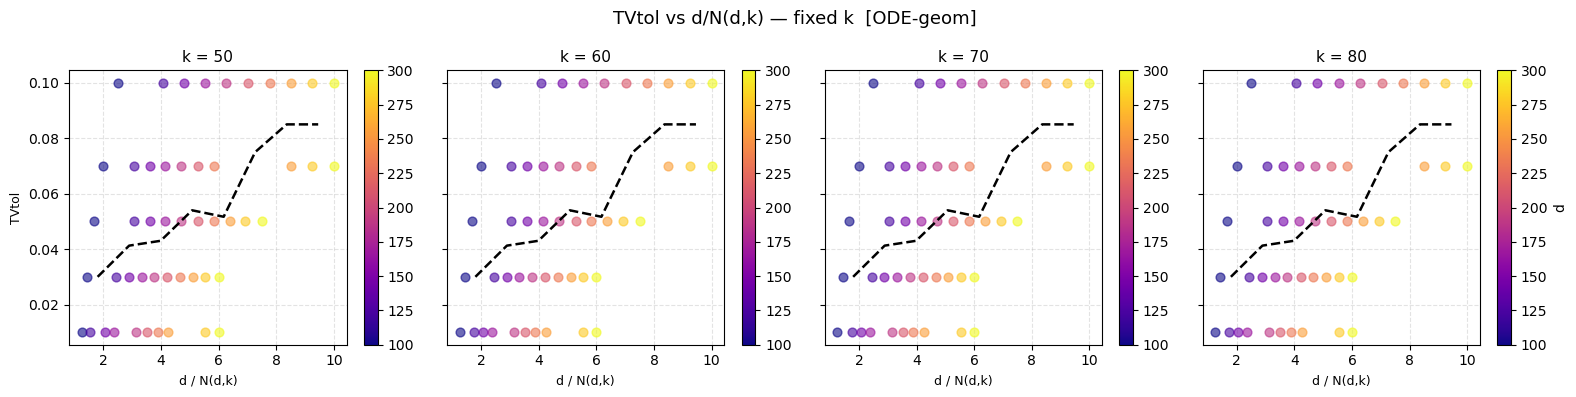

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

colors = ["#3266ad", "#d04a2f", "#2e8b57", "#8b2fc9"]  # one per fixed index

def plot_fixed_d(n_bins=8):
    """TVtol vs k/N(d,k), one subplot per fixed d."""
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
    axes = axes.flatten()

    for i, d in enumerate(DIMENSIONS):
        ax = axes[i]
        for j, k in enumerate(RANKS):
            # collect (ratio, tol) across all TVtol levels for this fixed (d, k)
            ratios, tols = [], []
            for tol, data in datasets.items():
                N = data[method_key][i][j]
                if not np.isinf(N) and N > 0:
                    ratios.append(k / N)
                    tols.append(tol)

            if ratios:
                ax.scatter(ratios, tols, color=colors[j], alpha=0.6, s=40,
                           label=f"k={k}", zorder=3)

        # mean trend across all k for this fixed d
        all_ratios, all_tols = [], []
        for tol, data in datasets.items():
            for j, k in enumerate(RANKS):
                N = data[method_key][i][j]
                if not np.isinf(N) and N > 0:
                    all_ratios.append(k / N)
                    all_tols.append(tol)

        if len(all_ratios) >= 3:
            means, edges, _ = binned_statistic(all_ratios, all_tols,
                                               statistic="mean", bins=n_bins)
            centers = 0.5 * (edges[:-1] + edges[1:])
            valid   = ~np.isnan(means)
            ax.plot(centers[valid], means[valid], color="black",
                    linewidth=1.8, linestyle="--", zorder=4, label="mean")

        ax.set_title(f"d = {d}", fontsize=11)
        ax.set_xlabel("k / N(d,k)", fontsize=9)
        if i % 5 == 0:
            ax.set_ylabel("TVtol", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.35)
        if i == 0:
            ax.legend(fontsize=7, title="rank k", title_fontsize=7)

    fig.suptitle("TVtol vs k/N(d,k) — fixed d  [ODE-geom]", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("TVtol_vs_kN_fixed_d.pdf", bbox_inches="tight")
    plt.show()


def plot_fixed_k(n_bins=8):
    """TVtol vs d/N(d,k), one subplot per fixed k."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for j, k in enumerate(RANKS):
        ax = axes[j]
        for i, d in enumerate(DIMENSIONS):
            ratios, tols = [], []
            for tol, data in datasets.items():
                N = data[method_key][i][j]
                if not np.isinf(N) and N > 0:
                    ratios.append(d / N)
                    tols.append(tol)

            if ratios:
                # use a colormap to distinguish d values
                c = plt.cm.plasma(i / (len(DIMENSIONS) - 1))
                ax.scatter(ratios, tols, color=c, alpha=0.6, s=40,
                           label=f"d={d}", zorder=3)

        # mean trend across all d for this fixed k
        all_ratios, all_tols = [], []
        for tol, data in datasets.items():
            for i, d in enumerate(DIMENSIONS):
                N = data[method_key][i][j]
                if not np.isinf(N) and N > 0:
                    all_ratios.append(d / N)
                    all_tols.append(tol)

        if len(all_ratios) >= 3:
            means, edges, _ = binned_statistic(all_ratios, all_tols,
                                               statistic="mean", bins=n_bins)
            centers = 0.5 * (edges[:-1] + edges[1:])
            valid   = ~np.isnan(means)
            ax.plot(centers[valid], means[valid], color="black",
                    linewidth=1.8, linestyle="--", zorder=4, label="mean")

        ax.set_title(f"k = {k}", fontsize=11)
        ax.set_xlabel("d / N(d,k)", fontsize=9)
        if j == 0:
            ax.set_ylabel("TVtol", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.35)

        # legend: show d colorbar instead of crowded legend
        sm = plt.cm.ScalarMappable(cmap="plasma",
                                   norm=plt.Normalize(min(DIMENSIONS), max(DIMENSIONS)))
        plt.colorbar(sm, ax=ax, label="d" if j == len(RANKS)-1 else "")

    fig.suptitle("TVtol vs d/N(d,k) — fixed k  [ODE-geom]", fontsize=13)
    plt.tight_layout()
    plt.savefig("TVtol_vs_dN_fixed_k.pdf", bbox_inches="tight")
    plt.show()


plot_fixed_d()
plot_fixed_k()

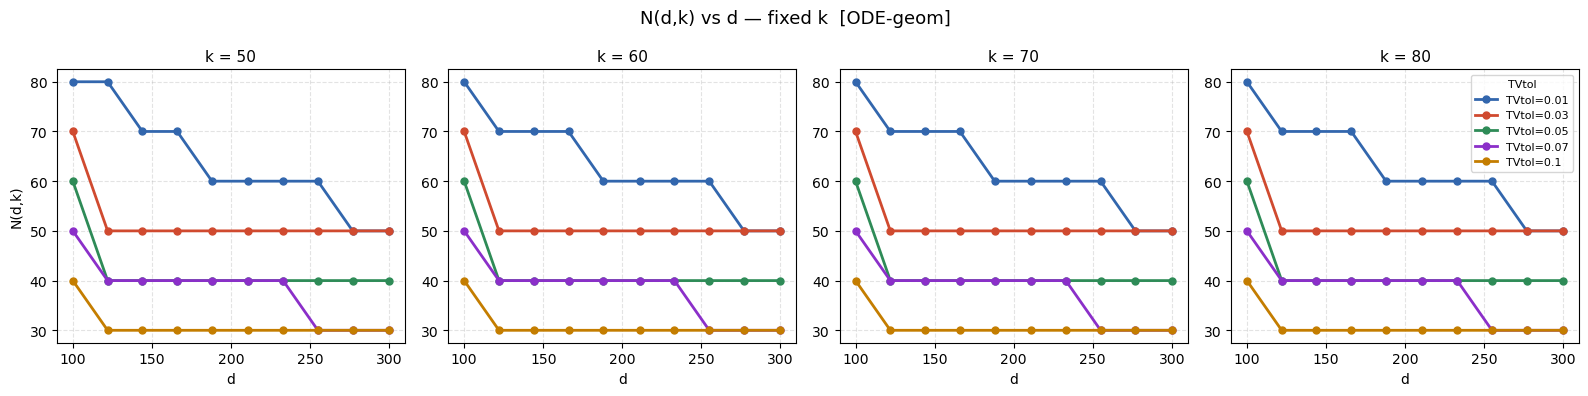

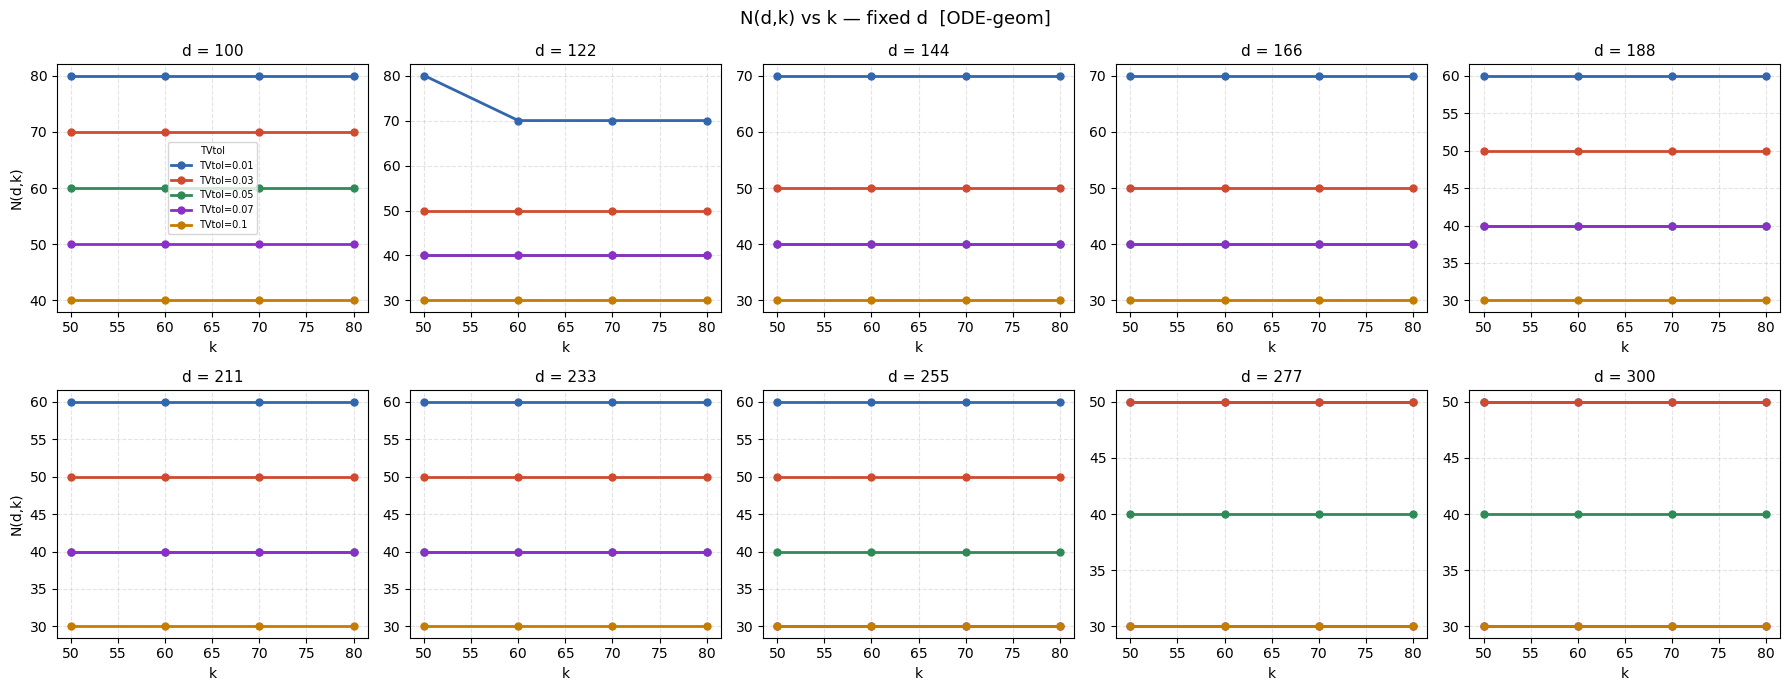

In [76]:
import numpy as np
import matplotlib.pyplot as plt

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

tol_colors = {0.01: "#3266ad", 0.03: "#d04a2f", 0.05: "#2e8b57",
              0.07: "#8b2fc9", 0.10: "#c47d00"}

def plot_N_vs_d_fixed_k():
    """N(d,k) vs d, one subplot per fixed k, one line per TVtol."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

    for j, k in enumerate(RANKS):
        ax = axes[j]
        for tol, data in datasets.items():
            N_vals = []
            d_vals = []
            for i, d in enumerate(DIMENSIONS):
                N = data[method_key][i][j]
                N_vals.append(N if not np.isinf(N) else np.nan)
                d_vals.append(d)

            ax.plot(d_vals, N_vals, marker="o", linewidth=2, markersize=5,
                    color=tol_colors[tol], label=f"TVtol={tol}")

        ax.set_title(f"k = {k}", fontsize=11)
        ax.set_xlabel("d", fontsize=10)
        if j == 0:
            ax.set_ylabel("N(d,k)", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.35)
        if j == len(RANKS) - 1:
            ax.legend(fontsize=8, title="TVtol", title_fontsize=8)

    fig.suptitle("N(d,k) vs d — fixed k  [ODE-geom]", fontsize=13)
    plt.tight_layout()
    plt.savefig("N_vs_d_fixed_k.pdf", bbox_inches="tight")
    plt.show()


def plot_N_vs_k_fixed_d():
    """N(d,k) vs k, one subplot per fixed d (2x5 grid), one line per TVtol."""
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
    axes = axes.flatten()

    for i, d in enumerate(DIMENSIONS):
        ax = axes[i]
        for tol, data in datasets.items():
            N_vals = []
            k_vals = []
            for j, k in enumerate(RANKS):
                N = data[method_key][i][j]
                N_vals.append(N if not np.isinf(N) else np.nan)
                k_vals.append(k)

            ax.plot(k_vals, N_vals, marker="o", linewidth=2, markersize=5,
                    color=tol_colors[tol], label=f"TVtol={tol}")

        ax.set_title(f"d = {d}", fontsize=11)
        ax.set_xlabel("k", fontsize=10)
        if i % 5 == 0:
            ax.set_ylabel("N(d,k)", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.35)
        if i == 0:
            ax.legend(fontsize=7, title="TVtol", title_fontsize=7)

    fig.suptitle("N(d,k) vs k — fixed d  [ODE-geom]", fontsize=13)
    plt.tight_layout()
    plt.savefig("N_vs_k_fixed_d.pdf", bbox_inches="tight")
    plt.show()


plot_N_vs_d_fixed_k()
plot_N_vs_k_fixed_d()

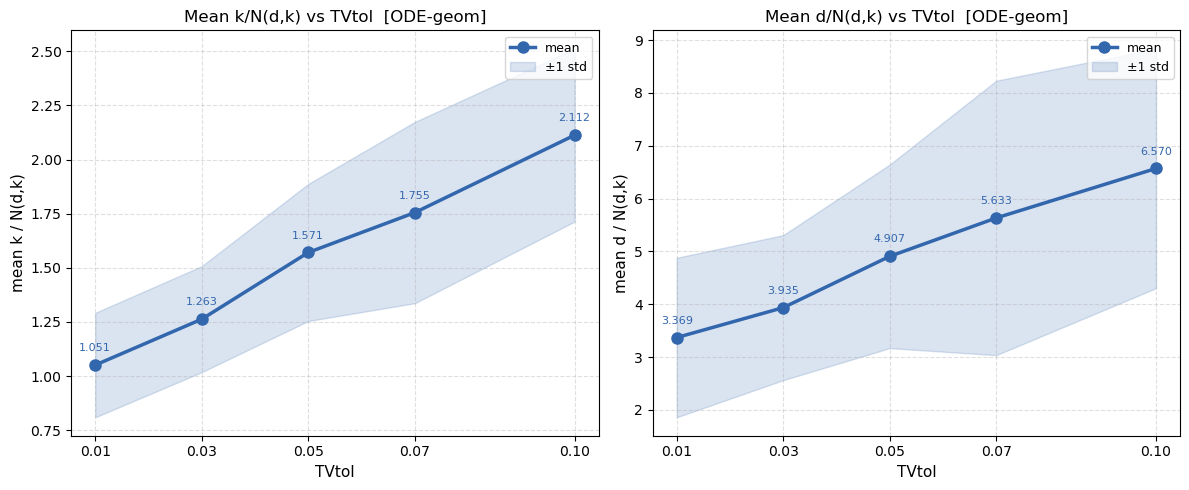

In [79]:
import numpy as np
import matplotlib.pyplot as plt

datasets   = {0.01: N1, 0.03: N2, 0.05: N3, 0.07: N4, 0.10: N5}
DIMENSIONS = [int(i) for i in np.linspace(100, 300, num=10)]
RANKS      = [int(i) for i in np.linspace(50,  80,  num=4)]
method_key = "N_ode_geom_matrix"

def compute_mean_ratio(numerator="k"):
    """For each TVtol, compute mean and std of k/N or d/N over all valid (d,k)."""
    tols, means, stds = [], [], []
    for tol, data in datasets.items():
        matrix = data[method_key]
        ratios = []
        for i, d in enumerate(DIMENSIONS):
            for j, k in enumerate(RANKS):
                N = matrix[i][j]
                if not np.isinf(N) and N > 0:
                    num = k if numerator == "k" else d
                    ratios.append(num / N)
        tols.append(tol)
        means.append(np.mean(ratios))
        stds.append(np.std(ratios))
    return np.array(tols), np.array(means), np.array(stds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, numerator, xlabel, title in [
    (axes[0], "k", "mean k / N(d,k)", "Mean k/N(d,k) vs TVtol  [ODE-geom]"),
    (axes[1], "d", "mean d / N(d,k)", "Mean d/N(d,k) vs TVtol  [ODE-geom]"),
]:
    tols, means, stds = compute_mean_ratio(numerator)
    order = np.argsort(tols)
    tols, means, stds = tols[order], means[order], stds[order]

    ax.plot(tols, means, marker="o", linewidth=2.5, markersize=8,
            color="#3266ad", zorder=3, label="mean")
    ax.fill_between(tols, means - stds, means + stds,
                    alpha=0.18, color="#3266ad", label="±1 std")

    # annotate each point with its value
    for t, m in zip(tols, means):
        ax.annotate(f"{m:.3f}", xy=(t, m), xytext=(0, 10),
                    textcoords="offset points", ha="center",
                    fontsize=8, color="#3266ad")

    ax.set_xlabel("TVtol", fontsize=11)
    ax.set_ylabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(tols)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mean_ratio_vs_TVtol.pdf", bbox_inches="tight")
plt.show()